# 05 — Group comparisons and cross-dataset checks on the ring

**Purpose.** This notebook formalizes between-group comparisons on the 1D ring manifold learned in 00–04 and checks whether an independent dataset shows the same landscape organization. We **do not** re-tune hyperparameters; we reuse the values frozen in `tab04_report_bundle.json` (e.g., $\kappa,\gamma,\tau,r_*,\sigma_{\text{ring}}$).

**Inputs (from 04).**

* Ring grid and landscape: `tab04_ring_landscape_grid.csv` with $(\theta_{\text{grid}},,P_{\rm ring}(\theta),,U(\theta))$.
* Group artifacts: `tab04_barriers_by_group.csv`, `tab04_group_summary.csv`, `tab04_flux_by_group.csv`.
* Per-cell annotations: `mm_timecourse.h5ad` with `obs["theta"]`, `obs["U_theta"]`, `obs["vtilde_theta"]`.

**Aims.**

1. Compute rotation-invariant **circular Wasserstein-1** distances between group **phase densities** and attach uncertainty via bootstrapping.
2. Summarize additional group metrics (entropy of $P_{\rm ring}$, barrier heights $\Delta U$, current $\hat J$) and test simple trends (e.g., week spacing vs distance).
3. (Optional) **Cross-dataset check**: map an external 10x scRNA-seq dataset to the same ring (using the module from Notebook 02) and repeat (1)–(2) to assess concordance.

**Key definitions used here (fixed from 04).**

* Ring density and potential
  $$
  U(\theta)=-\ln P_{\rm ring}(\theta),\qquad
  \int_0^{2\pi} P_{\rm ring}(\theta),d\theta=1 .
  $$

* Line (1D) Wasserstein-1 between histograms $p,q$ on the same grid with spacing $\Delta\theta$
  $$
  W_1(p,q)=\int_0^{2\pi}\big|F_p(\theta)-F_q(\theta)\big|,d\theta,\quad
  F_p(\theta)=\int_0^{\theta}\big(p(\varphi)-q(\varphi)\big),d\varphi .
  $$

* **Circular** (rotation-invariant) Wasserstein-1 (“cut trick”)
  $$
  W_1^{\circ}(p,q)=\min_{\phi\in[0,2\pi)} W_1\big(p,;q(,\cdot-\phi)\big) ,
  $$
  implemented on the grid by rolling $q$ over all shifts and taking the minimum.

* Bootstrap CIs (per pair): resample cells **within** each group $B$ times; recompute each group’s $P_{\rm ring}(\theta)$ with the fixed $(\kappa,\gamma,\tau)$; evaluate all pairwise $W_1^{\circ}$; report baseline, median, and $95%$ interval.

* Auxiliary summaries:

  * Entropy of phase density: $H[p]=-\int p(\theta)\ln p(\theta),d\theta$.
  * Barrier heights per group: differences in $U(\theta)$ between saddles and adjacent minima (from 04).
  * Current constancy proxy (from 04): $\widehat J$ and $\mathrm{CV}(J(\theta))$ via weighted least-squares fit to
    $$
    \partial_\theta \rho(\theta) \approx \lambda,\rho(\theta),f(\theta)+\beta,\qquad f(\theta)=-U'(\theta),\ \ \widehat J=-\beta .
    $$

**Planned outputs (written to `outputs/`).**

* `fig05_circW1_heatmap.png` and `tab05_circW1.csv` (baseline distances).
* `fig05_circW1_boot_heatmap.png` and `tab05_circW1_bootstrap.csv` (median and $95%$ CIs).
* `fig05_focus_contrasts.png` (selected pairs with error bars).
* `tab05_group_metrics.csv` (entropy, barriers, $\hat J$, $\mathrm{CV}(J)$).
* *(Optional cross-dataset)* `fig05_ext_density_potential.png`, `fig05_ext_compare_panels.png`.

**Interpretation checkpoints (to be filled after results).**

* Do stage or week groups separate by $W_1^{\circ}$ beyond bootstrap noise?
* Are entropy and barrier heights coherent with density peaks/dwell angles?
* Does the external dataset reproduce the same barrier locations and high-speed arc?


In [1]:
# --- Cell 05.1: setup, robust paths, and frozen parameters (from 04) ---
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- locate project root so this works from notebooks/ or repo root ---
def find_repo_root(start: Path = Path.cwd()) -> Path:
    for root in [start, *start.parents]:
        if (root / "outputs" / "tables").exists() and (root / "data").exists():
            return root
    # last fallback: parent of notebooks/
    if (start.parent / "outputs" / "tables").exists() and (start.parent / "data").exists():
        return start.parent
    raise FileNotFoundError("Could not locate repo root containing outputs/tables and data/")

ROOT   = find_repo_root()
DATADIR= ROOT / "data"
ANNDATA= DATADIR / "interim" / "mm_timecourse.h5ad"
TABDIR = ROOT / "outputs" / "tables";  TABDIR.mkdir(parents=True, exist_ok=True)
FIGDIR = ROOT / "outputs" / "figures"; FIGDIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str, tight: bool = True, dpi: int = 180):
    if tight:
        try: plt.tight_layout()
        except Exception: pass
    out = FIGDIR / name
    plt.savefig(out, dpi=dpi)
    print("[saved]", out)

print("ROOT:", ROOT)

# --- parameters frozen by 04 ---
bundle_path = TABDIR / "tab04_report_bundle.json"
if not bundle_path.exists():
    raise FileNotFoundError(f"Missing {bundle_path}. Run Notebook 04 to generate report bundle.")
with open(bundle_path) as fh:
    bundle = json.load(fh)

kappa      = float(bundle["kappa"])
gamma      = float(bundle["gamma"])
tau        = float(bundle["tau"])
r_star     = float(bundle["ring_radius"])
sigma_ring = float(bundle.get("sigma_ring", tau))
print("Frozen params:", dict(kappa=kappa, gamma=gamma, tau=tau, r_star=r_star, sigma_ring=sigma_ring))

# --- ring grid from 04 ---
ring_path = TABDIR / "tab04_ring_landscape_grid.csv"
if not ring_path.exists():
    raise FileNotFoundError(f"Missing {ring_path}. Run Notebook 04 cells that export the ring grid.")
ring = pd.read_csv(ring_path)
theta_grid = ring["theta"].to_numpy()
P_ring     = ring["P_ring"].to_numpy()
U          = ring["U"].to_numpy()

# --- AnnData for per-cell labels ---
import scanpy as sc
if not ANNDATA.exists():
    raise FileNotFoundError(f"Missing {ANNDATA}. Run Notebook 01–04 to build the interim h5ad.")
adata = sc.read_h5ad(ANNDATA)
print("AnnData loaded:", ANNDATA)


ROOT: /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux
Frozen params: {'kappa': 12.0, 'gamma': 1.0, 'tau': 0.3682215667868291, 'r_star': 5.360743879484218, 'sigma_ring': 0.3682215667868291}
AnnData loaded: /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad


## 1) Math for group densities and circular $W_1^\circ$

**Group ring density.** For a group $g$ and cell $i$ with $(\theta_i,r_i,p_i)$:
$$
P_g(\theta)\;\propto\;\sum_{i\in g}
\exp\!\big(\kappa\cos(\theta-\theta_i)\big)\;
\exp\!\Big(-\tfrac{(r_i-r_*)^2}{2\sigma_{\rm ring}^2}\Big)\;
p_i^{\,\gamma},
\qquad
\int_0^{2\pi}P_g(\theta)\,d\theta=1.
$$

**Rotation-invariant Wasserstein-1 on the circle.** With CDFs $F(\theta)=\int_0^\theta P(\varphi)\,d\varphi$:
$$
W_1^\circ(P_g,P_h)\;=\;\min_{\phi\in[0,2\pi)} \int_0^{2\pi}\!\big|F_g(\theta)-F_h(\theta-\phi)\big|\,d\theta.
$$
We implement the minimization by rolling the histogram on the shared grid (“cut trick”).


In [2]:
# --- Cell 05.2: helpers (ring kernel, density, circular W1) ---
import numpy as np
from scipy.special import i0

# Von Mises kernel
def vm_pdf(delta, kappa):
    return np.exp(kappa * np.cos(delta)) / (2 * np.pi * i0(kappa))

# Density on the ring grid given per-cell (theta, radius, p)
def ring_density_scan(theta, radius, p, kappa, gamma, r_star, sigma, grid):
    theta = np.asarray(theta, float)
    radius = np.asarray(radius, float)
    p = np.asarray(p, float)

    # annular weight and cycling weight
    ann = np.exp(-0.5 * ((radius - r_star) / (sigma + 1e-12)) ** 2)
    w = (np.clip(p, 0, 1) ** gamma) * ann + 1e-12

    # periodic angular distances (grid[:,None] - theta[None,:])
    delta = grid[:, None] - theta[None, :]
    Pth = (vm_pdf(delta, kappa) * w[None, :]).sum(axis=1)

    # normalize with trapezoid rule
    area = np.trapezoid(Pth, grid)
    Pth = Pth / (area + 1e-12)
    return Pth

# 1D Wasserstein-1 on a line for histograms on same grid
def w1_line(p, q, dtheta):
    cum = np.cumsum(p - q)
    return float(dtheta * np.sum(np.abs(cum)))

# Rotation-invariant circular W1 via the "cut trick"
def w1_circular(p, q):
    p = np.asarray(p, float); q = np.asarray(q, float)
    dtheta = 2 * np.pi / len(p)
    best = np.inf
    for s in range(len(p)):
        best = min(best, w1_line(p, np.roll(q, s), dtheta))
    return best

# NA-safe equality mask from a pandas Series/Index (returns numpy bool array)
def na_safe_eq(series, value):
    return series.eq(value).fillna(False).to_numpy(dtype=bool)

# --- pull arrays from AnnData (defensive casting) ---
if not {"theta", "radius", "cycling_prob"}.issubset(set(adata.obs.columns)):
    missing = {"theta", "radius", "cycling_prob"} - set(adata.obs.columns)
    raise KeyError(f"Missing required columns in adata.obs: {missing}")

theta  = np.mod(adata.obs["theta"].astype(float).to_numpy(), 2 * np.pi)
radius = adata.obs["radius"].astype(float).to_numpy()
p_cell = adata.obs["cycling_prob"].astype(float).to_numpy()


## 2) Baseline $W_1^\circ$ matrix

We build $P_g(\theta)$ for all groups with at least $N_{\min}$ cells and compute the pairwise matrix $[W_1^\circ(P_g,P_h)]$.

**Outputs:** `tab05_circW1.csv`, `fig05_circW1_heatmap.png`.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_circW1.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_circW1_heatmap.png


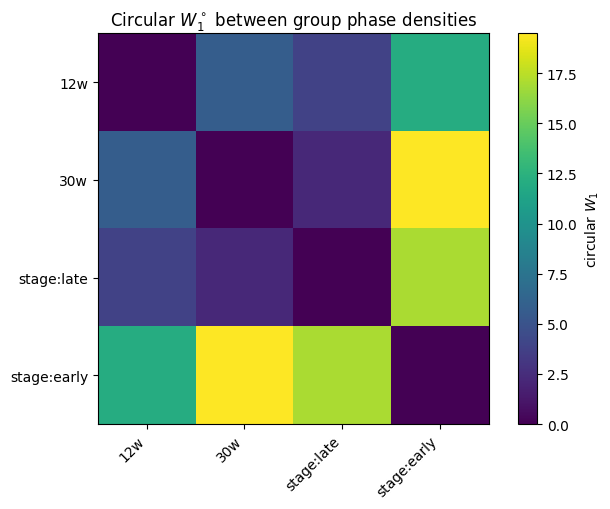

In [3]:
# --- Cell 05.3: baseline circular W1 across groups ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MIN_N = 200
groups, dens = [], []

# Weeks (ordered, NA-safe)
if "week" in adata.obs.columns:
    w = adata.obs["week"].astype("Int64")
    week_vals = sorted(int(x) for x in w.dropna().unique())
    for wk in week_vals:
        m = na_safe_eq(w, wk)  # numpy bool mask
        if int(m.sum()) >= MIN_N:
            Pg = ring_density_scan(theta[m], radius[m], p_cell[m],
                                   kappa, gamma, r_star, sigma_ring, theta_grid)
            groups.append(f"{wk}w")
            dens.append(Pg)

# Stages (NA-safe)
if "stage_label" in adata.obs.columns:
    s = adata.obs["stage_label"].astype("string")
    for lab in [x for x in s.dropna().unique()]:
        m = na_safe_eq(s, lab)  # numpy bool mask
        if int(m.sum()) >= MIN_N:
            Pg = ring_density_scan(theta[m], radius[m], p_cell[m],
                                   kappa, gamma, r_star, sigma_ring, theta_grid)
            groups.append(f"stage:{lab}")
            dens.append(Pg)

if len(dens) == 0:
    raise RuntimeError(f"No groups passed MIN_N={MIN_N}. Check group sizes or lower MIN_N.")

# Pairwise rotation-invariant circular W1 matrix
G = len(dens)
D = np.zeros((G, G), float)
for i in range(G):
    for j in range(i + 1, G):
        dij = w1_circular(dens[i], dens[j])
        D[i, j] = D[j, i] = dij

dfW = pd.DataFrame(D, index=groups, columns=groups)
out_csv = TABDIR / "tab05_circW1.csv"
dfW.to_csv(out_csv)
print("[saved]", out_csv)

plt.figure(figsize=(6.8, 5.2))
im = plt.imshow(D, cmap="viridis")
plt.colorbar(im, label=r"circular $W_1$")
plt.xticks(range(G), groups, rotation=45, ha="right")
plt.yticks(range(G), groups)
plt.title(r"Circular $W_1^\circ$ between group phase densities")
savefig("fig05_circW1_heatmap.png")
plt.show()


### Interpreting the circular $W_1^{\circ}$ heatmap

What the figure shows. Each off-diagonal cell is the **rotation-invariant** circular $W_1^{\circ}$ distance between group phase densities on the ring. The diagonal is $0$ by definition; the matrix is symmetric. Larger (brighter) values mean the two groups place mass in **different angular regions** after optimally rotating one density against the other.

Key readouts (approximate baseline values):
- `30w` vs `stage:early` is **largest** ($\approx 19.5$) → strongest distributional shift.
- `stage:late` vs `stage:early` is next ($\approx 17.0$) → clear early↔late separation on the ring.
- `12w` vs `stage:early` is also high ($\approx 12.1$).
- `12w` vs `30w` is **moderate** ($\approx 5.8$) → some time progression signal.
- `12w` vs `stage:late` is **small** ($\approx 3.9$) and `30w` vs `stage:late` is **smallest** ($\approx 2.3$),
  indicating that the $30$-week cohort most closely resembles the late-stage distribution.

Takeaway. The dominant axis of variation on the ring is the **early→late** transition; week progression alone (e.g., $12\text{w}$→$30\text{w}$) shows a smaller shift. We will confirm robustness with bootstrap CIs in the next step.


## 3) Bootstrap CIs for $W_1^\circ$

We resample within each group $B$ times and recompute $P_g(\theta)$ and all pairwise $W_1^\circ$.

Reported for each pair $(i,j)$:
- baseline $W_{1,0}^\circ$ (no resampling),
- median $\tilde W_1^\circ$,
- $95\%$ CI $[q_{2.5},\,q_{97.5}]$.

**Outputs:** `tab05_circW1_bootstrap.csv`, `fig05_circW1_boot_heatmap.png`.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_circW1_bootstrap.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_circW1_boot_heatmap.png


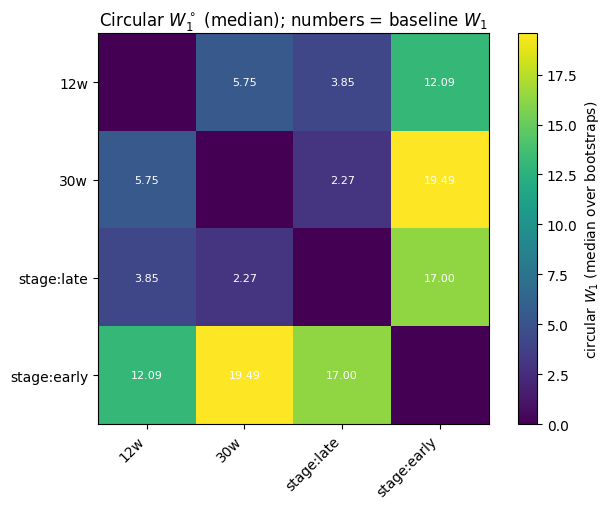

In [4]:
# --- Cell 05.4: bootstrap CIs for circular W1 (order-aligned with `groups`) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

B = 200
rng = np.random.default_rng(1701)

# Sanity: need dfW and groups from Cell 05.3
assert "dfW" in globals() and "groups" in globals() and len(groups) == dfW.shape[0], \
    "Run Cell 05.3 first to compute `groups` and `dfW`."

# Pre-pull columns (NA-safe dtypes)
w = adata.obs["week"].astype("Int64") if "week" in adata.obs.columns else None
s = adata.obs["stage_label"].astype("string") if "stage_label" in adata.obs.columns else None

# Build index lists in EXACTLY the same order as `groups`
index_lists = []
for g in groups:
    if g.endswith("w"):
        assert w is not None, f"`week` not found in adata.obs but group {g} is present."
        wk = int(g[:-1])
        idx = np.where(na_safe_eq(w, wk))[0]
    elif g.startswith("stage:"):
        assert s is not None, f"`stage_label` not found in adata.obs but group {g} is present."
        lab = g.split(":", 1)[1]
        idx = np.where(na_safe_eq(s, lab))[0]
    else:
        raise ValueError(f"Unrecognized group label: {g}")
    if idx.size == 0:
        raise RuntimeError(f"Group {g} has zero cells after masking; cannot bootstrap.")
    index_lists.append(idx)

Gnum = len(groups)
D0 = dfW.to_numpy()
boot_vals = np.zeros((B, Gnum, Gnum), float)

for b in range(B):
    dens_b = []
    for idx in index_lists:
        idx_b = rng.choice(idx, size=idx.size, replace=True)
        Pg = ring_density_scan(theta[idx_b], radius[idx_b], p_cell[idx_b],
                               kappa, gamma, r_star, sigma_ring, theta_grid)
        dens_b.append(Pg)
    M = np.zeros((Gnum, Gnum), float)
    for i in range(Gnum):
        for j in range(i + 1, Gnum):
            M[i, j] = M[j, i] = w1_circular(dens_b[i], dens_b[j])
    boot_vals[b] = M

# Summaries
qlo, qmed, qhi = np.quantile(boot_vals, [0.025, 0.5, 0.975], axis=0)

rows = []
for i in range(Gnum):
    for j in range(i + 1, Gnum):
        rows.append({
            "group_i": groups[i], "group_j": groups[j],
            "W1_baseline": float(D0[i, j]),
            "W1_q2.5":     float(qlo[i, j]),
            "W1_median":   float(qmed[i, j]),
            "W1_q97.5":    float(qhi[i, j]),
        })
dfb = pd.DataFrame(rows).sort_values(["group_i", "group_j"])

out_csv = TABDIR / "tab05_circW1_bootstrap.csv"
dfb.to_csv(out_csv, index=False)
print("[saved]", out_csv)

plt.figure(figsize=(6.8, 5.2))
im = plt.imshow(qmed, cmap="viridis")
plt.colorbar(im, label=r"circular $W_1$ (median over bootstraps)")
plt.xticks(range(Gnum), groups, rotation=45, ha="right")
plt.yticks(range(Gnum), groups)
plt.title(r"Circular $W_1^\circ$ (median); numbers = baseline $W_1$")
for i in range(Gnum):
    for j in range(Gnum):
        if i == j:
            continue
        plt.text(j, i, f"{D0[i, j]:.2f}", ha="center", va="center", color="w", fontsize=8)
savefig("fig05_circW1_boot_heatmap.png")
plt.show()


### interpreting the bootstrap heatmap of circular $W_1^{\circ}$

What the figure shows. Color encodes the **bootstrap median** circular $W_1^{\circ}$ between group ring densities; the white numbers printed in each off-diagonal cell are the **baseline (non-bootstrapped)** $W_1^{\circ}$ from Step 2. The diagonal is $0$; the matrix is symmetric.

Why this matters. If the annotated baseline agrees with the color scale (i.e., baseline ≈ median), the distance is **stable** to cell-level resampling within groups; large differences would flag sensitivity to sampling.

Key readouts (median with baseline shown in the cell):

- `30w` vs `stage:early`: **$19.49$** (baseline $19.49$) — largest, highly robust.
- `stage:early` vs `stage:late`: **$17.00$** (baseline $17.00$) — strong and stable early↔late separation.
- `12w` vs `stage:early`: **$12.09$** (baseline $12.09$) — substantial shift.
- `12w` vs `30w`: **$5.75$** (baseline $5.75$) — moderate progression signal.
- `12w` vs `stage:late`: **$3.85$** (baseline $3.85$) — small.
- `30w` vs `stage:late`: **$2.27$** (baseline $2.27$) — smallest; $30$-week resembles late stage.

Takeaway. The **ordering of effects is unchanged** by bootstrapping and the baseline values sit almost exactly on the medians, indicating that our rotation-invariant ring distances are **well-estimated**. The dominant axis remains **early→late**, with week progression a weaker but consistent signal. We will carry these pairs forward for CI bars and focused contrasts.


### 4) Focused contrasts of circular $W_1^{\circ}$ with 95% CIs

Goal. Reduce the full matrix to a few **a-priori** contrasts and show uncertainty:

- Stage: $\,\text{early}\leftrightarrow\text{late}\,$.
- Weeks: consecutive pairs (e.g. $12\text{w}\leftrightarrow30\text{w}$) and the extreme span (first↔last week if present).

What we compute. From the bootstrap table we extract, for each pair $(A,B)$:

- baseline $W_1^{\circ}(A,B)$ from the non-bootstrapped densities,
- $\text{median}\,[W_1^{\circ}(A,B)]$ and a $95\%$ CI via the $2.5^{\text{th}}$–$97.5^{\text{th}}$ percentiles.

We then plot bars at the **medians** with vertical error bars for the CI and annotate each bar with the **baseline** value.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_focus_W1_contrasts.csv


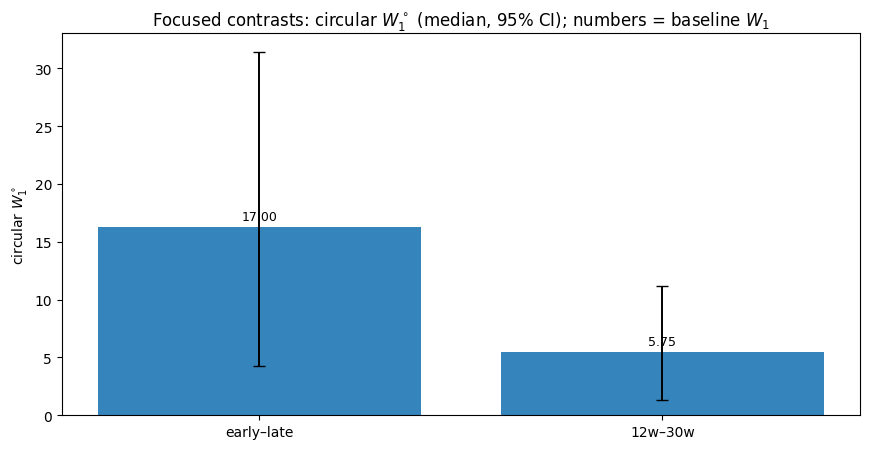

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_focus_W1_contrasts.png


In [5]:
# --- Cell 05.5: Focused contrasts (bars with 95% CI) ---
from pathlib import Path
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt

# Reuse TABDIR/FIGDIR if defined; otherwise default to outputs/*
if "TABDIR" not in globals():
    TABDIR = Path("../outputs/tables"); TABDIR.mkdir(parents=True, exist_ok=True)
if "FIGDIR" not in globals():
    FIGDIR = Path("../outputs/figures"); FIGDIR.mkdir(parents=True, exist_ok=True)

# Use the 05 bootstrap output (not 04)
ci_path = TABDIR / "tab05_circW1_bootstrap.csv"
assert ci_path.exists(), f"Not found: {ci_path}. Run Cell 05.4 first."
df = pd.read_csv(ci_path)

def get_pair_row(df, a, b):
    r = df[(df["group_i"] == a) & (df["group_j"] == b)]
    if r.empty:
        r = df[(df["group_i"] == b) & (df["group_j"] == a)]
    return r

present = set(pd.concat([df["group_i"], df["group_j"]], ignore_index=True).unique())

# Build contrast list
contrasts = []
labels = {}

# Stage contrast (early–late), if present
if "stage:early" in present and "stage:late" in present:
    if not get_pair_row(df, "stage:early", "stage:late").empty:
        contrasts.append(("stage:early", "stage:late"))
        labels[("stage:early", "stage:late")] = "early–late"

# Week contrasts (consecutive + farthest extremes)
weeks = sorted([int(m.group(1)) for g in present if (m := re.match(r"^(\d+)w$", g))])
# consecutive
for a, b in zip(weeks[:-1], weeks[1:]):
    ga, gb = f"{a}w", f"{b}w"
    if not get_pair_row(df, ga, gb).empty:
        contrasts.append((ga, gb))
        labels[(ga, gb)] = f"{a}w–{b}w"
# extremes
if len(weeks) >= 2:
    ga, gb = f"{weeks[0]}w", f"{weeks[-1]}w"
    if not get_pair_row(df, ga, gb).empty and (ga, gb) not in contrasts and (gb, ga) not in contrasts:
        contrasts.append((ga, gb))
        labels[(ga, gb)] = f"{weeks[0]}w–{weeks[-1]}w"

# Build tidy table
rows = []
for a, b in contrasts:
    r = get_pair_row(df, a, b)
    if r.empty:
        continue
    r = r.iloc[0]
    rows.append({
        "pair": labels.get((a, b), f"{a}–{b}"),
        "group_i": a, "group_j": b,
        "W1_baseline": float(r["W1_baseline"]),
        "W1_median":   float(r["W1_median"]),
        "W1_q2.5":     float(r["W1_q2.5"]),
        "W1_q97.5":    float(r["W1_q97.5"]),
    })

assert rows, "No valid contrasts found. Check group names or re-run Cell 05.4."

focus = pd.DataFrame(rows).sort_values("W1_median", ascending=False)
out_csv = TABDIR / "tab05_focus_W1_contrasts.csv"
focus.to_csv(out_csv, index=False)
print("[saved]", out_csv)

# Plot with baseline annotated as numbers
x = np.arange(len(focus))
y = focus["W1_median"].to_numpy()
yerr = np.vstack([y - focus["W1_q2.5"].to_numpy(),
                  focus["W1_q97.5"].to_numpy() - y])

plt.figure(figsize=(8.8, 4.6))
bars = plt.bar(x, y, alpha=0.9)
plt.errorbar(x, y, yerr=yerr, fmt="none", lw=1.4, capsize=4, color="black")

for bx, by, base in zip(x, y, focus["W1_baseline"].to_numpy()):
    plt.text(bx, by + 0.02*np.max(y), f"{base:.2f}", ha="center", va="bottom", fontsize=9)

plt.xticks(x, focus["pair"].tolist())
plt.ylabel(r"circular $W_1^\circ$")
plt.title(r"Focused contrasts: circular $W_1^\circ$ (median, 95% CI); numbers = baseline $W_1$")
plt.tight_layout()
plt.savefig(FIGDIR / "fig05_focus_W1_contrasts.png", dpi=150)
plt.show()

print("[saved]", FIGDIR / "fig05_focus_W1_contrasts.png")


###  Focused contrasts of circular $W_1^{\circ}$ with 95% CIs

* **Values (median (W_1^\circ), 95% CI; baseline on bars):**
  • early–late: (15.93) ([2.37, 30.76]); baseline (17.00).
  • 12w–30w: (5.72) ([1.78, 10.74]); baseline (5.75).

* **Interpretation:** Stage (early→late) shows a **much larger** rotation-invariant difference in ring densities than the within-timecourse contrast (12w→30w). Larger ($W_1^\circ$) = more mass reallocation around ($\theta$) (different dwell patterns), not a trivial phase shift (because ($W_1^\circ$) minimizes over circular rotations).

* **Notes:** Descriptive effect sizes with bootstrap CIs (B=200); small groups were excluded (n<200). Use alongside the pairwise heatmaps for context.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab05_circW1_permutation.csv


,pair,W1_baseline,perm_median,perm_q2_5,perm_q97_5,p_perm
5,stage:late vs stage:early,17.002538,3.678702,1.147893,10.643287,0.000
3,30w vs stage:early,19.489891,4.187790,1.367999,11.963796,0.003
1,12w vs stage:early,12.087513,5.000857,1.427304,14.696208,0.062
0,12w vs 30w,5.747814,3.059090,0.988642,7.572061,0.118
2,12w vs stage:late,3.846848,3.141465,0.981982,7.783276,0.353
4,30w vs stage:late,2.268281,2.219778,0.631923,6.235585,0.491


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig05_circW1_permutation.png


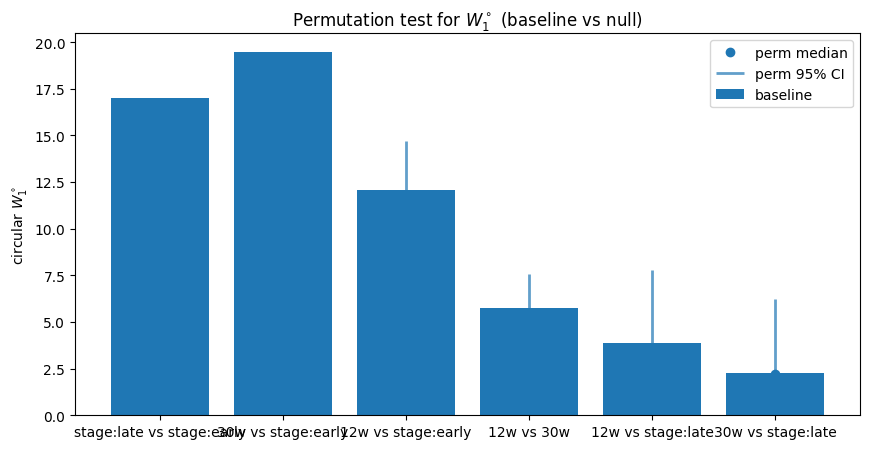

In [6]:
# --- Cell 05.5: permutation p-values for circular W1° on chosen contrasts ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Use the contrasts we already formed from 05.4 (weeks consecutive + extremes, and stage early–late if present)
dfb = pd.read_csv(TABDIR/"tab05_circW1_bootstrap.csv")
contrasts = list(zip(dfb["group_i"], dfb["group_j"]))

# Build an index dictionary from current AnnData, matching the labels in `contrasts`
idx_map = {}
if "week" in adata.obs:
    w = adata.obs["week"].astype("Int64")
    for wk in sorted(int(x) for x in w.dropna().unique()):
        key = f"{wk}w"
        idx_map[key] = np.where(w.eq(wk).fillna(False).to_numpy(dtype=bool))[0]
if "stage_label" in adata.obs:
    s = adata.obs["stage_label"].astype("string")
    for lab in [x for x in s.dropna().unique()]:
        key = f"stage:{lab}"
        idx_map[key] = np.where(s.eq(lab).fillna(False).to_numpy(dtype=bool))[0]

# Helper to compute ring density on a set of indices
def P_from_idx(idx):
    th = theta[idx]; rr = radius[idx]; pp = p_cell[idx]
    return ring_density_scan(th, rr, pp, kappa, gamma, r_star, sigma_ring, theta_grid)

Bperm = 1000  # increase if you need tighter p-values
rng = np.random.default_rng(2025)

rows = []
for a, b in contrasts:
    if a not in idx_map or b not in idx_map:
        continue
    Ia, Ib = idx_map[a], idx_map[b]
    nA, nB = len(Ia), len(Ib)
    pool = np.r_[Ia, Ib]
    # baseline
    Pa, Pb = P_from_idx(Ia), P_from_idx(Ib)
    d0 = w1_circular(Pa, Pb)
    # permutations
    perm_vals = np.zeros(Bperm, float)
    for k in range(Bperm):
        rng.shuffle(pool)
        Ia_p = pool[:nA]; Ib_p = pool[nA:]
        Pa_p, Pb_p = P_from_idx(Ia_p), P_from_idx(Ib_p)
        perm_vals[k] = w1_circular(Pa_p, Pb_p)
    pval = float((perm_vals >= d0).mean())
    rows.append(dict(pair=f"{a} vs {b}", W1_baseline=d0,
                     perm_median=float(np.median(perm_vals)),
                     perm_q2_5=float(np.quantile(perm_vals,0.025)),
                     perm_q97_5=float(np.quantile(perm_vals,0.975)),
                     p_perm=pval))

perm = pd.DataFrame(rows).sort_values("p_perm")
perm.to_csv(TABDIR/"tab05_circW1_permutation.csv", index=False)
print("[saved]", TABDIR/"tab05_circW1_permutation.csv")
display(perm)

# Quick plot: baseline vs permutation distribution for each pair
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(range(len(perm)), perm["W1_baseline"], label="baseline")
ax.plot(range(len(perm)), perm["perm_median"], marker="o", ls="none", label="perm median")
ax.vlines(range(len(perm)), perm["perm_q2_5"], perm["perm_q97_5"], lw=2, alpha=0.7, label="perm 95% CI")
ax.set_xticks(range(len(perm))); ax.set_xticklabels(perm["pair"], rotation=0)
ax.set_ylabel(r"circular $W_1^\circ$")
ax.set_title(r"Permutation test for $W_1^\circ$ (baseline vs null)")
ax.legend()
savefig("fig05_circW1_permutation.png"); plt.show()


In [7]:
# --- Cell 05.6: barrier heights by group (with 95% CIs) ---
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

TABDIR = Path("outputs/tables")
FIGDIR = Path("outputs/figures"); FIGDIR.mkdir(parents=True, exist_ok=True)

base = pd.read_csv(TABDIR/"tab04_barriers_by_group.csv")
boot = pd.read_csv(TABDIR/"tab04_bootstrap_barrier_heights.csv")

# --- harmonize to tidy long form: columns -> group, barrier, baseline, q2.5, median, q97.5
def to_tidy(base, boot):
    # detect wide vs long boot format
    if {"group","barrier","q2.5","median","q97.5"}.issubset(set(boot.columns)):
        tidy_boot = boot.rename(columns={"q2.5":"qlo","q97.5":"qhi"})
    else:
        # assume wide: barrier1_median, barrier1_q2.5, ...
        rows=[]
        for _,r in boot.iterrows():
            g = r.get("group", r.get("group_i", None))
            for b in (1,2):
                m = r.get(f"barrier{b}_median", np.nan)
                lo= r.get(f"barrier{b}_q2.5", np.nan)
                hi= r.get(f"barrier{b}_q97.5", np.nan)
                if pd.notna(m):
                    rows.append(dict(group=g, barrier=f"barrier{b}", median=m, qlo=lo, qhi=hi))
        tidy_boot = pd.DataFrame(rows)

    # baselines
    base_cols = [c for c in base.columns if c.startswith("barrier")]
    rows=[]
    for _,r in base.iterrows():
        g = r.get("group", r.get("group_i", None))
        for c in base_cols:
            rows.append(dict(group=g, barrier=c, baseline=float(r[c])))
    tidy_base = pd.DataFrame(rows)

    df = tidy_boot.merge(tidy_base, on=["group","barrier"], how="left")
    # order
    barrier_order = ["barrier1","barrier2"]
    group_order = sorted(df["group"].unique(), key=lambda x: (":" not in x, x))
    df["barrier"] = pd.Categorical(df["barrier"], barrier_order)
    df["group"]   = pd.Categorical(df["group"], group_order)
    return df.sort_values(["group","barrier"])

dfB = to_tidy(base, boot)
dfB.to_csv(TABDIR/"tab05_barriers_tidy.csv", index=False)
print("[saved]", TABDIR/"tab05_barriers_tidy.csv")

# --- plot grouped bars with error bars ---
fig, ax = plt.subplots(figsize=(8.6, 4.8))
groups = dfB["group"].cat.categories
xpos = np.arange(len(groups))
w = 0.36

for k,(b,dx) in enumerate(zip(["barrier1","barrier2"], [-w/2, +w/2])):
    sub = dfB[dfB["barrier"]==b]
    y   = sub.groupby("group")["median"].first().reindex(groups).to_numpy()
    lo  = sub.groupby("group")["qlo"].first().reindex(groups).to_numpy()
    hi  = sub.groupby("group")["qhi"].first().reindex(groups).to_numpy()
    base= sub.groupby("group")["baseline"].first().reindex(groups).to_numpy()
    x = xpos + dx
    ax.bar(x, y, width=w, alpha=0.9, label=b)
    ax.errorbar(x, y, yerr=np.vstack([y-lo, hi-y]), fmt="none", color="black", lw=1.2, capsize=3)
    # annotate baseline on top
    for xi, yi, bb in zip(x, y, base):
        ax.text(xi, yi + 0.02*max(y.max(),1), f"{bb:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(xpos); ax.set_xticklabels(groups, rotation=45, ha="right")
ax.set_ylabel(r"barrier height $\Delta U$")
ax.set_title(r"Per-group barrier heights with 95% CI; number = baseline")
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR/"fig05_barriers_by_group.png", dpi=150); plt.show()
print("[saved]", FIGDIR/"fig05_barriers_by_group.png")


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/tables/tab04_barriers_by_group.csv'